# Week 2 - Linear Regression, Part 2

# Analysis



This is a part of the Capstone Project. This week the following models will be used:
- Lasso Regression
- Ridge Regression
- Net Elastic Regression

# Datasets

## All Datasets

In [1]:
# Shared imports for classification modeling (used by all datasets below)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import (LinearRegression, LogisticRegression,
                                   Lasso, Ridge, ElasticNet,
                                   LassoCV, RidgeCV, ElasticNetCV)
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                              mean_squared_error, mean_absolute_error, r2_score,
                              explained_variance_score)

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:
pd.set_option('display.max_columns', 100)

In [3]:
# Shared helpers for regularized regression modeling (used by all datasets below)
def compute_vif(X):
    """Variance Inflation Factor for every column of X (VIF_i = 1 / (1 - R^2) from
    regressing feature i on all the other columns of X). VIF > 5 is often treated as
    a caution, VIF > 10 as a serious multicollinearity problem."""
    vifs = {}
    for col in X.columns:
        y_i = X[col].values
        X_rest = X.drop(columns=[col]).values
        r2 = LinearRegression().fit(X_rest, y_i).score(X_rest, y_i)
        vifs[col] = np.inf if r2 >= 1 - 1e-8 else 1.0 / (1.0 - r2)
    return pd.Series(vifs, name="VIF").sort_values(ascending=False)

def fit_and_report(model, X_train, y_train, X_test, y_test, label):
    """Fit a (regularized) linear model and report R^2 / RMSE / MAE on the held-out test set."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    mae = mean_absolute_error(y_test, y_pred)
    print(f"{label:38s} R^2={r2:8.4f}   RMSE={rmse:14,.2f}   MAE={mae:14,.2f}")
    return model, {"model": label, "R2": r2, "RMSE": rmse, "MAE": mae}

def to_protocol_category(protocol_col):
    """Map the numeric CICFlowMeter Protocol code to a readable categorical label."""
    mapping = {6: "TCP", 17: "UDP"}
    return protocol_col.map(lambda p: mapping.get(int(p), "OTHER"))

def to_port_tier(port_col):
    """Bin a destination-port column into the standard IANA categorical tiers - used as
    a categorical feature when a dataset has no explicit Protocol column."""
    def tier(p):
        p = int(p)
        if p < 1024:
            return "well_known"
        elif p < 49152:
            return "registered"
        else:
            return "dynamic"
    return port_col.apply(tier)


## Dataset 1: Malware

### Setup

In [4]:
# Load the dataset
files = [
    "malware_benign_1.csv",
    "malware_benign_2.csv",
    "malware_benign_3.csv",
    "malware_benign_4.csv",
    "malware_benign_5.csv",
    "malware_benign_6.csv",
    "malware_benign_7.csv",
    "malware_benign_8.csv",
    "malware_benign_9.csv",
    "malware_benign_10.csv",
    "malware_benign_11.csv",
    "malware_benign_12.csv",
    "malware_benign_13.csv",
    "malware_benign_14.csv",
    "malware_benign_15.csv",
    "ransomware_wannalocker_1.csv",
    "ransomware_wannalocker_2.csv",
    "ransomware_wannalocker_3.csv",
    "ransomware_wannalocker_4.csv",
    "ransomware_wannalocker_5.csv",
    "ransomware_wannalocker_6.csv",
    "ransomware_wannalocker_7.csv",
    "ransomware_wannalocker_8.csv",
    "ransomware_wannalocker_9.csv"
]

dfs = []
for f in files:
    df = pd.read_csv(f)
    df.columns = df.columns.str.strip()  # source CSVs have inconsistent leading spaces in headers
    dfs.append(df)

ransomware_df = pd.concat(dfs, ignore_index=True)
print(ransomware_df.shape)

(37839, 85)


In [5]:
# Print the dataset
ransomware_df.head()

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,172.217.2.174-10.42.0.211-443-51023-6,10.42.0.211,51023,172.217.2.174,443,6,16/06/2017 03:55:47,151054,6,8,1076.0,4575.0,821.0,0.0,179.333333,321.621931,1418.0,0.0,571.875000,679.532284,37410.462484,92.682087,11619.538462,14541.155884,49105.0,24.0,101887.0,20377.4,12821.550737,30425.0,111.0,128516.0,18359.428571,24038.557859,54822.0,24.0,0,0,0,0,200,264,39.720895,52.961193,0.0,1418.0,376.733333,562.514948,316423.066667,0,0,0,1,0,0,0,0,1.0,403.642857,179.333333,571.875000,200,0,0,0,0,0,0,6,1076,8,4575,65535,353,3,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1,172.217.2.174-10.42.0.211-443-51023-6,10.42.0.211,51023,172.217.2.174,443,6,16/06/2017 03:55:47,349,2,0,23.0,0.0,23.0,0.0,11.500000,16.263456,0.0,0.0,0.000000,0.000000,65902.578797,5730.659026,349.000000,0.000000,349.0,349.0,349.0,349.0,0.000000,349.0,349.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,64,0,5730.659026,0.000000,0.0,23.0,15.333333,13.279056,176.333333,0,1,0,0,1,0,0,0,0.0,23.000000,11.500000,0.000000,64,0,0,0,0,0,0,2,23,0,0,1594,-1,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2,172.217.12.174-10.42.0.211-443-34259-6,10.42.0.211,34259,172.217.12.174,443,6,16/06/2017 03:55:52,119,2,0,23.0,0.0,23.0,0.0,11.500000,16.263456,0.0,0.0,0.000000,0.000000,193277.310924,16806.722689,119.000000,0.000000,119.0,119.0,119.0,119.0,0.000000,119.0,119.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,64,0,16806.722689,0.000000,0.0,23.0,15.333333,13.279056,176.333333,0,1,0,0,1,0,0,0,0.0,23.000000,11.500000,0.000000,64,0,0,0,0,0,0,2,23,0,0,1486,-1,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
3,172.217.10.74-10.42.0.211-443-55509-6,10.42.0.211,55509,172.217.10.74,443,6,16/06/2017 03:55:53,37055,1,1,31.0,0.0,31.0,31.0,31.000000,0.000000,0.0,0.0,0.000000,0.000000,836.594252,53.973823,37055.000000,0.000000,37055.0,37055.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,32,32,26.986911,26.986911,0.0,31.0,20.666667,17.897858,320.333333,0,1,0,0,1,0,0,0,1.0,31.000000,31.000000,0.000000,32,0,0,0,0,0,0,1,31,1,0,1548,391,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
4,172.217.2.174-10.42.0.211-443-44852-6,10.42.0.211,44852,172.217.2.174,443,6,16/06/2017 03:55:58,178727,6,7,1313.0,307.0,753.0,0.0,218.833333,331.306152,168.0,0.0,43.857143,75.366722,9064.103353,72.736632,14893.916667,18532.640750,62243.0,55.0,125550.0,25110.0,28468.232023,70464.0,172.0,156011.0,26001.833333,24955.901822,67743.0,55.0,0,0,0,0,200,232,33.570753,39.165879,0.0,753.0,115.714286,231.422833,53556.527473,0,0,0,1,0,0,0,0,1.0,124.615385,218.833333,43.857143,200,0,0,0,0,0,0,6,1313,7,307,65535,352,3,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


In [6]:
# Map the label column to numeric classes
print("Before:", ransomware_df['Label'].unique())

ransomware_df['Label'] = np.where(ransomware_df['Label'].str.strip().str.upper() == 'BENIGN', 0, 1)

print("After:", ransomware_df['Label'].unique())
ransomware_df['Label'].value_counts()

Before: <StringArray>
['BENIGN', 'RANSOMWARE_WANNALOCKER']
Length: 2, dtype: str
After: [0 1]


Label
1    29769
0     8070
Name: count, dtype: int64

In [7]:
# Drop duplicate rows
before = len(ransomware_df)
ransomware_df = ransomware_df.drop_duplicates()
print(f"Dropped {before - len(ransomware_df)} duplicate rows -> {len(ransomware_df)} rows remaining")

Dropped 0 duplicate rows -> 37839 rows remaining


In [8]:
# Drop null & NaN values
before = len(ransomware_df)
ransomware_df = ransomware_df.dropna()  # covers both nulls and NaNs
print(f"Dropped {before - len(ransomware_df)} rows with null/NaN values -> {len(ransomware_df)} rows remaining")

Dropped 0 rows with null/NaN values -> 37839 rows remaining


In [9]:
# Drop negative values
before = len(ransomware_df)
numeric_cols = ransomware_df.select_dtypes(include=[np.number]).columns

# Init_Win_bytes_forward / Init_Win_bytes_backward use -1 as a sentinel meaning
# "no forward/backward-direction window observed" (not invalid data), so they are
# excluded from the negative-value check.
negative_check_cols = numeric_cols.drop(['Init_Win_bytes_forward', 'Init_Win_bytes_backward'])

negative_mask = (ransomware_df[negative_check_cols] < 0).any(axis=1)
ransomware_df = ransomware_df[~negative_mask]
print(f"Dropped {before - len(ransomware_df)} rows containing negative values (excluding Init_Win_bytes_forward/backward) -> {len(ransomware_df)} rows remaining")

Dropped 28 rows containing negative values (excluding Init_Win_bytes_forward/backward) -> 37811 rows remaining


In [10]:
# Drop non-numeric columns
non_numeric_cols = ransomware_df.select_dtypes(exclude=[np.number]).columns.tolist()
print("Dropping non-numeric columns:", non_numeric_cols)

ransomware_df = ransomware_df.drop(columns=non_numeric_cols)
print(ransomware_df.shape)

Dropping non-numeric columns: ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp']
(37811, 81)


In [11]:
# Drop perfectly correlated columns
corr_matrix = ransomware_df.drop(columns=['Label']).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

perfectly_correlated = [col for col in upper.columns if (upper[col] >= 0.999).any()]
print(f"Dropping {len(perfectly_correlated)} columns with ~1.00 correlation to an earlier column:")
print(perfectly_correlated)

ransomware_df = ransomware_df.drop(columns=perfectly_correlated)
print(ransomware_df.shape)

Dropping 8 columns with ~1.00 correlation to an earlier column:
['SYN Flag Count', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Fwd Header Length.1', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes']
(37811, 73)


In [12]:
# Drop duplicate rows (post feature engineering)
before = len(ransomware_df)
ransomware_df = ransomware_df.drop_duplicates()
print(f"Dropped {before - len(ransomware_df)} duplicate rows -> {len(ransomware_df)} rows remaining")

Dropped 2 duplicate rows -> 37809 rows remaining


In [13]:
# Print clean dataset
ransomware_df.head()

,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,51023,443,6,151054,6,8,1076.0,4575.0,821.0,0.0,179.333333,321.621931,1418.0,0.0,571.875000,679.532284,37410.462484,92.682087,11619.538462,14541.155884,49105.0,24.0,101887.0,20377.4,12821.550737,30425.0,111.0,128516.0,18359.428571,24038.557859,54822.0,24.0,0,0,0,0,200,264,39.720895,52.961193,0.0,1418.0,376.733333,562.514948,316423.066667,0,0,1,0,0,0,0,1.0,403.642857,0,0,0,0,0,0,65535,353,3,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,51023,443,6,349,2,0,23.0,0.0,23.0,0.0,11.500000,16.263456,0.0,0.0,0.000000,0.000000,65902.578797,5730.659026,349.000000,0.000000,349.0,349.0,349.0,349.0,0.000000,349.0,349.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,64,0,5730.659026,0.000000,0.0,23.0,15.333333,13.279056,176.333333,0,0,0,1,0,0,0,0.0,23.000000,0,0,0,0,0,0,1594,-1,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,34259,443,6,119,2,0,23.0,0.0,23.0,0.0,11.500000,16.263456,0.0,0.0,0.000000,0.000000,193277.310924,16806.722689,119.000000,0.000000,119.0,119.0,119.0,119.0,0.000000,119.0,119.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,64,0,16806.722689,0.000000,0.0,23.0,15.333333,13.279056,176.333333,0,0,0,1,0,0,0,0.0,23.000000,0,0,0,0,0,0,1486,-1,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,55509,443,6,37055,1,1,31.0,0.0,31.0,31.0,31.000000,0.000000,0.0,0.0,0.000000,0.000000,836.594252,53.973823,37055.000000,0.000000,37055.0,37055.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,32,32,26.986911,26.986911,0.0,31.0,20.666667,17.897858,320.333333,0,0,0,1,0,0,0,1.0,31.000000,0,0,0,0,0,0,1548,391,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,44852,443,6,178727,6,7,1313.0,307.0,753.0,0.0,218.833333,331.306152,168.0,0.0,43.857143,75.366722,9064.103353,72.736632,14893.916667,18532.640750,62243.0,55.0,125550.0,25110.0,28468.232023,70464.0,172.0,156011.0,26001.833333,24955.901822,67743.0,55.0,0,0,0,0,200,232,33.570753,39.165879,0.0,753.0,115.714286,231.422833,53556.527473,0,0,1,0,0,0,0,1.0,124.615385,0,0,0,0,0,0,65535,352,3,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [14]:
# Sanity check
print("Any nulls left:", ransomware_df.isnull().values.any())
print("Any negatives left:", (ransomware_df < 0).values.any())
print("Any duplicate rows left:", ransomware_df.duplicated().any())
print("All columns numeric:", all(np.issubdtype(dt, np.number) for dt in ransomware_df.dtypes))
print("\nFinal shape:", ransomware_df.shape)
print("\nLabel counts:")
print(ransomware_df['Label'].value_counts())

Any nulls left: False
Any negatives left: True
Any duplicate rows left: False
All columns numeric: True

Final shape: (37809, 73)

Label counts:
Label
1    29764
0     8045
Name: count, dtype: int64


In [15]:
# Export cleaned data to CSV
ransomware_df.to_csv("ransomware_combined_clean.csv", index=False)
print("Saved ransomware_combined_clean.csv")

Saved ransomware_combined_clean.csv


### Regression Analysis

Goal: model **Flow Duration** (microseconds) - a continuous outcome - as a function of
packet/byte-count features and the flow's **Protocol** (TCP vs. UDP vs. other), a
categorical feature. Part 1 handled the multicollinearity among these features by
computing a variance inflation factor (VIF) and manually dropping the worst offenders.
This section applies the same modeling frame but swaps in **regularized regression** -
Lasso (L1), Ridge (L2), and Elastic Net (L1 + L2) - which handle multicollinearity
automatically by shrinking correlated coefficients instead of removing features by
hand. Because regularization penalizes coefficients by magnitude, every feature is
standardized with `StandardScaler` before fitting.


In [16]:
# Build the modeling frame: continuous predictors + a categorical Protocol feature
target_col = "Flow Duration"

continuous_candidates = [
    "Total Fwd Packets", "Total Backward Packets",
    "Total Length of Fwd Packets", "Total Length of Bwd Packets",
    "Packet Length Mean", "Flow IAT Mean",
]
continuous_cols = [c for c in continuous_candidates if c in ransomware_df.columns]

model_df = ransomware_df[[target_col] + continuous_cols].copy()

if "Protocol" in ransomware_df.columns:
    model_df["protocol_cat"] = to_protocol_category(ransomware_df["Protocol"])
else:
    model_df["protocol_cat"] = to_port_tier(ransomware_df["Destination Port"])

# Flow Duration of 0 means the flow was instantaneous / not meaningfully observed
model_df = model_df[model_df[target_col] > 0].dropna()

print("Continuous predictors:", continuous_cols)
print("Categorical predictor: protocol_cat ->", model_df["protocol_cat"].value_counts().to_dict())
print("Modeling frame shape:", model_df.shape)
model_df.head()


Continuous predictors: ['Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Packet Length Mean', 'Flow IAT Mean']
Categorical predictor: protocol_cat -> {'TCP': 29161, 'UDP': 8382, 'OTHER': 266}
Modeling frame shape: (37809, 8)


,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Packet Length Mean,Flow IAT Mean,protocol_cat
0,151054,6,8,1076.0,4575.0,376.733333,11619.538462,TCP
1,349,2,0,23.0,0.0,15.333333,349.000000,TCP
2,119,2,0,23.0,0.0,15.333333,119.000000,TCP
3,37055,1,1,31.0,0.0,20.666667,37055.000000,TCP
4,178727,6,7,1313.0,307.0,115.714286,14893.916667,TCP


In [17]:
# One-hot encode the categorical feature, split into train/test, and scale
cat_dummies = pd.get_dummies(model_df["protocol_cat"], prefix="protocol", drop_first=True)
X_all = pd.concat([model_df[continuous_cols], cat_dummies], axis=1).astype(float)
y_all = model_df[target_col].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=RANDOM_STATE
)

# Regularized regression penalizes coefficients by magnitude, so every feature needs to
# be on the same scale - fit the scaler on the training data only, then apply it to both.
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Design matrix columns:", X_all.columns.tolist())
print("Train/test sizes:", X_train.shape, X_test.shape)


Design matrix columns: ['Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Packet Length Mean', 'Flow IAT Mean', 'protocol_TCP', 'protocol_UDP']
Train/test sizes: (30247, 8) (7562, 8)


#### Model 1: Lasso Regression

In [18]:
# Model 1: Lasso Regression (L1) - alpha chosen by cross-validation, main effects only
results = []
lasso_cv = LassoCV(cv=5, random_state=RANDOM_STATE, max_iter=10000)
model_1, r = fit_and_report(lasso_cv, X_train_scaled, y_train, X_test_scaled, y_test, "Model 1: Lasso Regression")
results.append(r)
print(f"Selected alpha: {model_1.alpha_:.5f}")

coef_table = pd.Series(model_1.coef_, index=X_all.columns).sort_values(key=abs, ascending=False)
print("\nCoefficients (zero = dropped by L1):")
print(coef_table)


Model 1: Lasso Regression              R^2=  0.4543   RMSE= 16,351,993.27   MAE=  8,998,721.48
Selected alpha: 11200.41429

Coefficients (zero = dropped by L1):
Total Backward Packets         1.108513e+08
Total Length of Bwd Packets   -1.082284e+08
protocol_UDP                  -1.450714e+07
protocol_TCP                  -1.289827e+07
Flow IAT Mean                  1.124250e+07
Total Length of Fwd Packets   -3.694971e+06
Packet Length Mean             2.881936e+06
Total Fwd Packets             -1.635436e+06
dtype: float64


In [19]:
# Multicollinearity check: Variance Inflation Factor among the continuous predictors
vif_before = compute_vif(X_train[continuous_cols])
print("VIF - continuous predictors only:")
print(vif_before)

n_high = int((vif_before > 10).sum())
print(f"\n{n_high} of {len(vif_before)} continuous predictors exceed the VIF > 10 rule of thumb - "
      f"Lasso, Ridge, and Elastic Net below all handle this automatically, without dropping features by hand.")


VIF - continuous predictors only:
Total Backward Packets         291.968092
Total Length of Bwd Packets    254.457614
Total Fwd Packets                4.754133
Packet Length Mean               1.416340
Total Length of Fwd Packets      1.142335
Flow IAT Mean                    1.036597
Name: VIF, dtype: float64

2 of 6 continuous predictors exceed the VIF > 10 rule of thumb - Lasso, Ridge, and Elastic Net below all handle this automatically, without dropping features by hand.


#### Model 2: Ridge Regression

In [20]:
# Model 2: Ridge Regression (L2) - alpha chosen by cross-validation, same full feature set
# as Model 1. Unlike Lasso, Ridge shrinks correlated coefficients toward each other rather
# than zeroing them out, so every feature stays in the model.
ridge_cv = RidgeCV(alphas=np.logspace(-3, 3, 13), cv=5)
model_2, r = fit_and_report(ridge_cv, X_train_scaled, y_train, X_test_scaled, y_test, "Model 2: Ridge Regression")
results.append(r)
print(f"Selected alpha: {model_2.alpha_:.5f}")

coef_table = pd.Series(model_2.coef_, index=X_all.columns).sort_values(key=abs, ascending=False)
print("\nCoefficients:")
print(coef_table)


Model 2: Ridge Regression              R^2=  0.4541   RMSE= 16,354,340.38   MAE=  8,965,956.97
Selected alpha: 1.00000

Coefficients:
Total Backward Packets         1.154211e+08
Total Length of Bwd Packets   -1.124481e+08
protocol_UDP                  -1.511291e+07
protocol_TCP                  -1.352098e+07
Flow IAT Mean                  1.122568e+07
Total Length of Fwd Packets   -3.877306e+06
Packet Length Mean             2.839202e+06
Total Fwd Packets             -2.000070e+06
dtype: float64


#### Model 3: Elastic Net Regression

In [21]:
# Model 3: Elastic Net Regression (L1 + L2), fit on the full feature set plus polynomial &
# interaction terms for two of the continuous features. Part 1 kept this expansion small
# because an unregularized model overfit badly on a wider set of squared/interaction terms;
# Elastic Net's combined penalty is specifically built to tolerate exactly that kind of
# expanded, correlated feature set, so this doubles as a check on that idea.
mean_like = [c for c in continuous_cols if "Mean" in c or "avg" in c.lower()]
poly_features = mean_like[:2] if len(mean_like) >= 2 else continuous_cols[:2]
print("Features expanded with PolynomialFeatures:", poly_features)

poly = PolynomialFeatures(degree=2, include_bias=False)
poly_arr_train = poly.fit_transform(X_train[poly_features])
poly_arr_test = poly.transform(X_test[poly_features])
poly_names = poly.get_feature_names_out(poly_features)
poly_train_df = pd.DataFrame(poly_arr_train, columns=poly_names, index=X_train.index)
poly_test_df = pd.DataFrame(poly_arr_test, columns=poly_names, index=X_test.index)

other_cols = [c for c in X_train.columns if c not in poly_features]
X_train_3 = pd.concat([poly_train_df, X_train[other_cols]], axis=1)
X_test_3 = pd.concat([poly_test_df, X_test[other_cols]], axis=1)

scaler_3 = StandardScaler()
X_train_3_scaled = pd.DataFrame(scaler_3.fit_transform(X_train_3), columns=X_train_3.columns, index=X_train_3.index)
X_test_3_scaled = pd.DataFrame(scaler_3.transform(X_test_3), columns=X_test_3.columns, index=X_test_3.index)

print("New polynomial/interaction feature names:", poly_names.tolist())

elastic_cv = ElasticNetCV(l1_ratio=[.1, .5, .7, .9, .95, .99, 1], cv=5, random_state=RANDOM_STATE, max_iter=10000)
model_3, r = fit_and_report(elastic_cv, X_train_3_scaled, y_train, X_test_3_scaled, y_test, "Model 3: Elastic Net Regression")
results.append(r)
print(f"Selected alpha: {model_3.alpha_:.5f}   l1_ratio: {model_3.l1_ratio_}")


Features expanded with PolynomialFeatures: ['Packet Length Mean', 'Flow IAT Mean']
New polynomial/interaction feature names: ['Packet Length Mean', 'Flow IAT Mean', 'Packet Length Mean^2', 'Packet Length Mean Flow IAT Mean', 'Flow IAT Mean^2']
Model 3: Elastic Net Regression        R^2=  0.6571   RMSE= 12,961,343.63   MAE=  6,308,475.51
Selected alpha: 11239.59589   l1_ratio: 1.0


### Comparison

                                       R2          RMSE           MAE
model                                                                
Model 1: Lasso Regression        0.454252  1.635199e+07  8.998721e+06
Model 2: Ridge Regression        0.454095  1.635434e+07  8.965957e+06
Model 3: Elastic Net Regression  0.657113  1.296134e+07  6.308476e+06


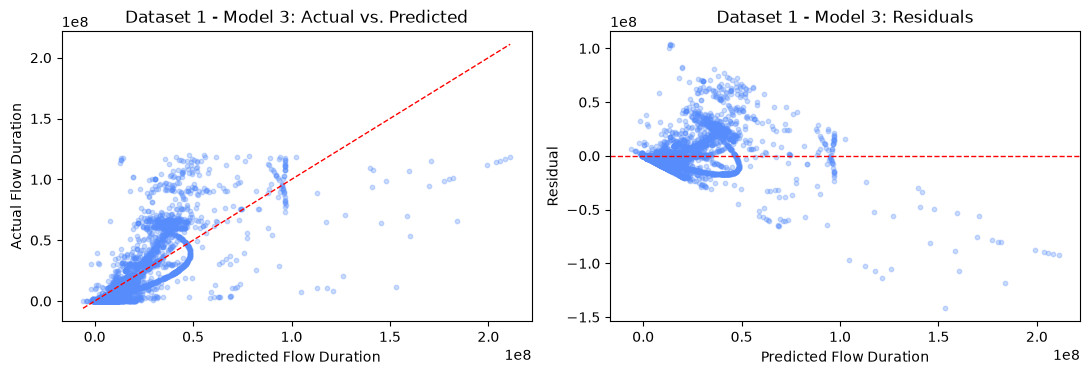

In [22]:
# Compare all three models, and inspect residuals for the final model
comparison = pd.DataFrame(results).set_index("model")
print(comparison)

y_pred_final = model_3.predict(X_test_3_scaled)
residuals = y_test.values - y_pred_final

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(y_pred_final, y_test, alpha=0.3, s=10)
lims = [min(y_test.min(), y_pred_final.min()), max(y_test.max(), y_pred_final.max())]
axes[0].plot(lims, lims, "r--", linewidth=1)
axes[0].set_xlabel("Predicted Flow Duration")
axes[0].set_ylabel("Actual Flow Duration")
axes[0].set_title("Dataset 1 - Model 3: Actual vs. Predicted")

axes[1].scatter(y_pred_final, residuals, alpha=0.3, s=10)
axes[1].axhline(0, color="r", linestyle="--", linewidth=1)
axes[1].set_xlabel("Predicted Flow Duration")
axes[1].set_ylabel("Residual")
axes[1].set_title("Dataset 1 - Model 3: Residuals")

plt.tight_layout()
plt.show()


**Dataset 1 takeaways (37,809-row cleaned dataset):** Lasso and Ridge land almost exactly on top of each other (R^2 = 0.454 vs. 0.454) and barely move off the Part 1 OLS baseline (0.454) - at their cross-validated alphas, neither penalty is strong enough to zero out the Total Backward Packets / Total Length of Bwd Packets pair (VIF ~292 and ~254), so Lasso keeps all eight coefficients nonzero, just shrunk. That is a useful contrast with Part 1's Model 2, where manually *dropping* one of those features actually hurt accuracy (R^2 fell to 0.380) - regularization's gentler shrinkage avoids that penalty entirely, at the cost of not really solving the multicollinearity either. Elastic Net, once the same Packet Length Mean / Flow IAT Mean polynomial and interaction terms from Part 1 are added, jumps to R^2 = 0.657 - the best of the six models across both parts of this assignment - and its cross-validated l1_ratio of 1.0 means the extra L2 term added nothing here; the redundancy in this dataset is apparently sparse enough that pure L1 was preferred.

## Dataset 2: Intrusion

### Setup

In [23]:
# Load the dataset

# Load and combine the datasets
files = [
    "network_traffic_1.csv",
    "network_traffic_2.csv",
    "network_traffic_3.csv",
    "network_traffic_4.csv",
    "network_traffic_5.csv",
    "network_traffic_6.csv",
    "network_traffic_7.csv",
    "network_traffic_8.csv"
]

# First read in as string to accommodate special character in Label column
dfs = []
for f in files:
    df = pd.read_csv(f, encoding="latin1", dtype=str)
    df.columns = df.columns.str.strip()  # source CSVs have inconsistent leading spaces in headers
    dfs.append(df)

intrusion_df = pd.concat(dfs, ignore_index=True)

# Convert numeric columns to numbers
numeric_candidates = [c for c in intrusion_df.columns if c != 'Label']
intrusion_df[numeric_candidates] = intrusion_df[numeric_candidates].apply(pd.to_numeric, errors='coerce')

# Infinity parses to np.inf rather than NaN — if you want those treat as missing/dropped like NaN
intrusion_df[numeric_candidates] = intrusion_df[numeric_candidates].replace([np.inf, -np.inf], np.nan)

print(intrusion_df.shape)

(2830743, 79)


In [24]:
# Print the dataset
intrusion_df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,33,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,1.100917e+05,18348.62385,109.0,0.0,109,109,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,9174.311927,9174.311927,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,2.307692e+05,38461.53846,52.0,0.0,52,52,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,19230.769230,19230.769230,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,3.529412e+05,58823.52941,34.0,0.0,34,34,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,29411.764710,29411.764710,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,31,329,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,32,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [25]:
# Normalize the Label column

# Where 0: 'BENIGN', 1: 'Bot', 2: 'DDoS', 3: 'DoS GoldenEye', 4: 'DoS Hulk', 5: 'DoS Slowhttptest',
# 6: 'DoS slowloris', 7: 'FTP-Patator', 8: 'Heartbleed', 9: 'Infiltration', 10: 'PortScan', 11: 'SSH-Patator',
# 12: 'Web Attack - Brute Force', 13: 'Web Attack - Sql Injection', 14: 'Web Attack - XSS'
intrusion_df["Label"] = (
    intrusion_df["Label"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
    .str.replace(r"Web Attack.*Brute Force", "Web Attack - Brute Force", regex=True)
    .str.replace(r"Web Attack.*Sql Injection", "Web Attack - Sql Injection", regex=True)
    .str.replace(r"Web Attack.*XSS", "Web Attack - XSS", regex=True)
)

# Build mapping from all unique label strings to integers
classes = sorted(intrusion_df["Label"].unique())
label_to_int = {label: i for i, label in enumerate(classes)}

with np.printoptions(threshold=np.inf):
    print("Before:", intrusion_df["Label"].astype("string").unique())

    intrusion_df["Label"] = intrusion_df["Label"].map(label_to_int)

    print("After:", intrusion_df["Label"].unique())

print(intrusion_df["Label"].value_counts())

Before: <StringArray>
[                    'BENIGN',                       'DDoS',
                   'PortScan',                        'Bot',
               'Infiltration',   'Web Attack - Brute Force',
           'Web Attack - XSS', 'Web Attack - Sql Injection',
                'FTP-Patator',                'SSH-Patator',
              'DoS slowloris',           'DoS Slowhttptest',
                   'DoS Hulk',              'DoS GoldenEye',
                 'Heartbleed']
Length: 15, dtype: string
After: [ 0  2 10  1  9 12 14 13  7 11  6  5  4  3  8]
Label
0     2273097
4      231073
10     158930
2      128027
3       10293
7        7938
11       5897
6        5796
5        5499
1        1966
12       1507
14        652
9          36
13         21
8          11
Name: count, dtype: int64


In [26]:
# Drop duplicate rows
before = len(intrusion_df)
intrusion_df = intrusion_df.drop_duplicates()
print(f"Dropped {before - len(intrusion_df)} duplicate rows -> {len(intrusion_df)} rows remaining")

Dropped 308381 duplicate rows -> 2522362 rows remaining


In [27]:
# Drop null & NaN values
before = len(intrusion_df)
intrusion_df = intrusion_df.dropna()  # covers both nulls and NaNs
print(f"Dropped {before - len(intrusion_df)} rows with null/NaN values -> {len(intrusion_df)} rows remaining")

Dropped 1564 rows with null/NaN values -> 2520798 rows remaining


In [28]:
# Drop negative values
before = len(intrusion_df)
numeric_cols = intrusion_df.select_dtypes(include=[np.number]).columns

# Init_Win_bytes_forward / Init_Win_bytes_backward use -1 as a sentinel meaning
# "no forward/backward-direction window observed" (not invalid data), so they are
# excluded from the negative-value check — same fix already applied to ransomware.
negative_check_cols = numeric_cols.drop(['Init_Win_bytes_forward', 'Init_Win_bytes_backward'])

negative_mask = (intrusion_df[negative_check_cols] < 0).any(axis=1)
intrusion_df = intrusion_df[~negative_mask]
print(f"Dropped {before - len(intrusion_df)} rows containing negative values (excluding Init_Win_bytes_forward/backward) -> {len(intrusion_df)} rows remaining")

Dropped 2915 rows containing negative values (excluding Init_Win_bytes_forward/backward) -> 2517883 rows remaining


In [29]:
# Drop non-numeric columns
non_numeric_cols = intrusion_df.select_dtypes(exclude=[np.number]).columns.tolist()
print("Dropping non-numeric columns:", non_numeric_cols)

intrusion_df = intrusion_df.drop(columns=non_numeric_cols)
print(intrusion_df.shape)

Dropping non-numeric columns: []
(2517883, 79)


In [30]:
# Drop perfectly correlated columns
corr_matrix = intrusion_df.drop(columns=['Label']).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

perfectly_correlated = [col for col in upper.columns if (upper[col] >= 0.999).any()]
print(f"Dropping {len(perfectly_correlated)} columns with ~1.00 correlation to an earlier column:")
print(perfectly_correlated)

intrusion_df = intrusion_df.drop(columns=perfectly_correlated)
print(intrusion_df.shape)

Dropping 9 columns with ~1.00 correlation to an earlier column:
['SYN Flag Count', 'CWE Flag Count', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Fwd Header Length.1', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes']
(2517883, 70)


In [31]:
# Drop duplicate rows (post feature engineering)
before = len(intrusion_df)
intrusion_df = intrusion_df.drop_duplicates()
print(f"Dropped {before - len(intrusion_df)} duplicate rows -> {len(intrusion_df)} rows remaining")

Dropped 0 duplicate rows -> 2517883 rows remaining


In [32]:
# Print cleaned DataFrame
intrusion_df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,1,0,0,0,9.0,0,0,0,0,0,0,33,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,0
1,55054,109,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,1.100917e+05,18348.62385,109.0,0.0,109,109,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,9174.311927,9174.311927,6,6,6.0,0.0,0.0,0,0,0,1,1,0,1,9.0,0,0,0,0,0,0,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,0
2,55055,52,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,2.307692e+05,38461.53846,52.0,0.0,52,52,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,19230.769230,19230.769230,6,6,6.0,0.0,0.0,0,0,0,1,1,0,1,9.0,0,0,0,0,0,0,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,0
3,46236,34,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,3.529412e+05,58823.52941,34.0,0.0,34,34,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,29411.764710,29411.764710,6,6,6.0,0.0,0.0,0,0,0,1,1,0,1,9.0,0,0,0,0,0,0,31,329,0,20,0.0,0.0,0,0,0.0,0.0,0,0,0
4,54863,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,1,0,0,0,9.0,0,0,0,0,0,0,32,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,0


In [33]:
# Sanity check
print("Any nulls left:", intrusion_df.isnull().values.any())
print("Any negatives left:", (intrusion_df < 0).values.any())
print("Any duplicate rows left:", intrusion_df.duplicated().any())
print("All columns numeric:", all(np.issubdtype(dt, np.number) for dt in intrusion_df.dtypes))
print("\nFinal shape:", intrusion_df.shape)
print("\nLabel counts:")
print(intrusion_df['Label'].value_counts())

Any nulls left: False
Any negatives left: True
Any duplicate rows left: False
All columns numeric: True

Final shape: (2517883, 70)

Label counts:
Label
0     2092335
4      172688
2      127995
10      90694
3       10281
7        5927
6        5385
5        5228
11       3217
1        1948
12       1470
14        652
9          35
13         21
8           7
Name: count, dtype: int64


In [34]:
# Export cleaned data to CSV
intrusion_df.to_csv("intrusion_newtork_traffic_clean.csv", index=False)
print("Saved intrusion_newtork_traffic_clean.csv")

Saved intrusion_newtork_traffic_clean.csv


### Regression Analysis

Goal: model **Flow Duration** (microseconds) - a continuous outcome - as a function of
packet/byte-count features and the flow's **Protocol** (TCP vs. UDP vs. other), a
categorical feature. Part 1 handled the multicollinearity among these features by
computing a variance inflation factor (VIF) and manually dropping the worst offenders.
This section applies the same modeling frame but swaps in **regularized regression** -
Lasso (L1), Ridge (L2), and Elastic Net (L1 + L2) - which handle multicollinearity
automatically by shrinking correlated coefficients instead of removing features by
hand. Because regularization penalizes coefficients by magnitude, every feature is
standardized with `StandardScaler` before fitting.

Same target as the malware dataset - **Flow Duration** - so the two flow-based datasets can be compared directly. This dataset has no Protocol column, so the categorical feature here is a **destination-port tier** (well-known / registered / dynamic).


In [35]:
# Build the modeling frame: continuous predictors + a categorical Protocol feature
target_col = "Flow Duration"

continuous_candidates = [
    "Total Fwd Packets", "Total Backward Packets",
    "Total Length of Fwd Packets", "Total Length of Bwd Packets",
    "Packet Length Mean", "Flow IAT Mean",
]
continuous_cols = [c for c in continuous_candidates if c in intrusion_df.columns]

model_df = intrusion_df[[target_col] + continuous_cols].copy()

if "Protocol" in intrusion_df.columns:
    model_df["protocol_cat"] = to_protocol_category(intrusion_df["Protocol"])
else:
    model_df["protocol_cat"] = to_port_tier(intrusion_df["Destination Port"])

# Flow Duration of 0 means the flow was instantaneous / not meaningfully observed
model_df = model_df[model_df[target_col] > 0].dropna()

print("Continuous predictors:", continuous_cols)
print("Categorical predictor: protocol_cat ->", model_df["protocol_cat"].value_counts().to_dict())
print("Modeling frame shape:", model_df.shape)
model_df.head()


Continuous predictors: ['Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Packet Length Mean', 'Flow IAT Mean']
Categorical predictor: protocol_cat -> {'well_known': 1971689, 'dynamic': 302561, 'registered': 243633}
Modeling frame shape: (2517883, 8)


,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Packet Length Mean,Flow IAT Mean,protocol_cat
0,3,2,0,12,0,6.0,3.0,dynamic
1,109,1,1,6,6,6.0,109.0,dynamic
2,52,1,1,6,6,6.0,52.0,dynamic
3,34,1,1,6,6,6.0,34.0,registered
4,3,2,0,12,0,6.0,3.0,dynamic


In [36]:
# One-hot encode the categorical feature, split into train/test, and scale
cat_dummies = pd.get_dummies(model_df["protocol_cat"], prefix="port_tier", drop_first=True)
X_all = pd.concat([model_df[continuous_cols], cat_dummies], axis=1).astype(float)
y_all = model_df[target_col].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=RANDOM_STATE
)

# Regularized regression penalizes coefficients by magnitude, so every feature needs to
# be on the same scale - fit the scaler on the training data only, then apply it to both.
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Design matrix columns:", X_all.columns.tolist())
print("Train/test sizes:", X_train.shape, X_test.shape)


Design matrix columns: ['Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Packet Length Mean', 'Flow IAT Mean', 'port_tier_registered', 'port_tier_well_known']
Train/test sizes: (2014306, 8) (503577, 8)


#### Model 1: Lasso Regression

In [37]:
# Model 1: Lasso Regression (L1) - alpha chosen by cross-validation, main effects only
results = []
lasso_cv = LassoCV(cv=5, random_state=RANDOM_STATE, max_iter=10000)
model_1, r = fit_and_report(lasso_cv, X_train_scaled, y_train, X_test_scaled, y_test, "Model 1: Lasso Regression")
results.append(r)
print(f"Selected alpha: {model_1.alpha_:.5f}")

coef_table = pd.Series(model_1.coef_, index=X_all.columns).sort_values(key=abs, ascending=False)
print("\nCoefficients (zero = dropped by L1):")
print(coef_table)


Model 1: Lasso Regression              R^2=  0.4232   RMSE= 26,789,907.22   MAE= 14,973,850.90
Selected alpha: 216577.61260

Coefficients (zero = dropped by L1):
Total Fwd Packets              4.047332e+07
Total Length of Bwd Packets   -3.904799e+07
Flow IAT Mean                  1.642345e+07
Packet Length Mean             1.069586e+07
Total Length of Fwd Packets   -2.924441e+06
port_tier_well_known           1.844948e+06
Total Backward Packets         0.000000e+00
port_tier_registered          -0.000000e+00
dtype: float64


In [38]:
# Multicollinearity check: Variance Inflation Factor among the continuous predictors
vif_before = compute_vif(X_train[continuous_cols])
print("VIF - continuous predictors only:")
print(vif_before)

n_high = int((vif_before > 10).sum())
print(f"\n{n_high} of {len(vif_before)} continuous predictors exceed the VIF > 10 rule of thumb - "
      f"Lasso, Ridge, and Elastic Net below all handle this automatically, without dropping features by hand.")


VIF - continuous predictors only:
Total Backward Packets         140.843121
Total Fwd Packets               98.155220
Total Length of Bwd Packets     82.229796
Total Length of Fwd Packets      1.638937
Packet Length Mean               1.054246
Flow IAT Mean                    1.032714
Name: VIF, dtype: float64

3 of 6 continuous predictors exceed the VIF > 10 rule of thumb - Lasso, Ridge, and Elastic Net below all handle this automatically, without dropping features by hand.


#### Model 2: Ridge Regression

In [39]:
# Model 2: Ridge Regression (L2) - alpha chosen by cross-validation, same full feature set
# as Model 1. Unlike Lasso, Ridge shrinks correlated coefficients toward each other rather
# than zeroing them out, so every feature stays in the model.
ridge_cv = RidgeCV(alphas=np.logspace(-3, 3, 13), cv=5)
model_2, r = fit_and_report(ridge_cv, X_train_scaled, y_train, X_test_scaled, y_test, "Model 2: Ridge Regression")
results.append(r)
print(f"Selected alpha: {model_2.alpha_:.5f}")

coef_table = pd.Series(model_2.coef_, index=X_all.columns).sort_values(key=abs, ascending=False)
print("\nCoefficients:")
print(coef_table)


Model 2: Ridge Regression              R^2=  0.3924   RMSE= 27,495,944.05   MAE= 14,511,532.97
Selected alpha: 1000.00000

Coefficients:
Total Length of Bwd Packets   -6.729998e+07
Total Fwd Packets              5.387673e+07
Flow IAT Mean                  1.665031e+07
Total Backward Packets         1.512067e+07
Packet Length Mean             1.062178e+07
Total Length of Fwd Packets   -5.366002e+06
port_tier_well_known           1.679964e+06
port_tier_registered           1.614612e+04
dtype: float64


#### Model 3: Elastic Net Regression

In [40]:
# Model 3: Elastic Net Regression (L1 + L2), fit on the full feature set plus polynomial &
# interaction terms for two of the continuous features. Part 1 kept this expansion small
# because an unregularized model overfit badly on a wider set of squared/interaction terms;
# Elastic Net's combined penalty is specifically built to tolerate exactly that kind of
# expanded, correlated feature set, so this doubles as a check on that idea.
mean_like = [c for c in continuous_cols if "Mean" in c or "avg" in c.lower()]
poly_features = mean_like[:2] if len(mean_like) >= 2 else continuous_cols[:2]
print("Features expanded with PolynomialFeatures:", poly_features)

poly = PolynomialFeatures(degree=2, include_bias=False)
poly_arr_train = poly.fit_transform(X_train[poly_features])
poly_arr_test = poly.transform(X_test[poly_features])
poly_names = poly.get_feature_names_out(poly_features)
poly_train_df = pd.DataFrame(poly_arr_train, columns=poly_names, index=X_train.index)
poly_test_df = pd.DataFrame(poly_arr_test, columns=poly_names, index=X_test.index)

other_cols = [c for c in X_train.columns if c not in poly_features]
X_train_3 = pd.concat([poly_train_df, X_train[other_cols]], axis=1)
X_test_3 = pd.concat([poly_test_df, X_test[other_cols]], axis=1)

scaler_3 = StandardScaler()
X_train_3_scaled = pd.DataFrame(scaler_3.fit_transform(X_train_3), columns=X_train_3.columns, index=X_train_3.index)
X_test_3_scaled = pd.DataFrame(scaler_3.transform(X_test_3), columns=X_test_3.columns, index=X_test_3.index)

print("New polynomial/interaction feature names:", poly_names.tolist())

elastic_cv = ElasticNetCV(l1_ratio=[.1, .5, .7, .9, .95, .99, 1], cv=5, random_state=RANDOM_STATE, max_iter=10000)
model_3, r = fit_and_report(elastic_cv, X_train_3_scaled, y_train, X_test_3_scaled, y_test, "Model 3: Elastic Net Regression")
results.append(r)
print(f"Selected alpha: {model_3.alpha_:.5f}   l1_ratio: {model_3.l1_ratio_}")


Features expanded with PolynomialFeatures: ['Packet Length Mean', 'Flow IAT Mean']
New polynomial/interaction feature names: ['Packet Length Mean', 'Flow IAT Mean', 'Packet Length Mean^2', 'Packet Length Mean Flow IAT Mean', 'Flow IAT Mean^2']
Model 3: Elastic Net Regression        R^2=  0.6171   RMSE= 21,826,214.78   MAE= 10,304,295.23
Selected alpha: 140744.37241   l1_ratio: 1.0


### Comparison

                                       R2          RMSE           MAE
model                                                                
Model 1: Lasso Regression        0.423169  2.678991e+07  1.497385e+07
Model 2: Ridge Regression        0.392364  2.749594e+07  1.451153e+07
Model 3: Elastic Net Regression  0.617120  2.182621e+07  1.030430e+07


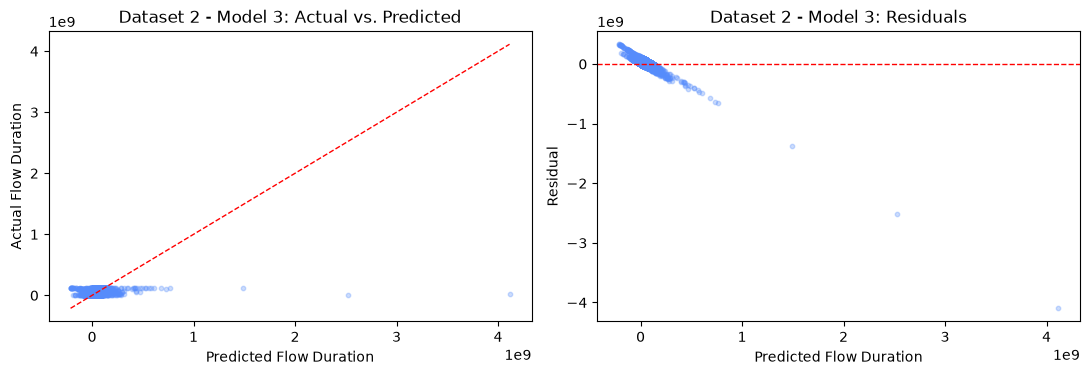

In [41]:
# Compare all three models, and inspect residuals for the final model
comparison = pd.DataFrame(results).set_index("model")
print(comparison)

y_pred_final = model_3.predict(X_test_3_scaled)
residuals = y_test.values - y_pred_final

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(y_pred_final, y_test, alpha=0.3, s=10)
lims = [min(y_test.min(), y_pred_final.min()), max(y_test.max(), y_pred_final.max())]
axes[0].plot(lims, lims, "r--", linewidth=1)
axes[0].set_xlabel("Predicted Flow Duration")
axes[0].set_ylabel("Actual Flow Duration")
axes[0].set_title("Dataset 2 - Model 3: Actual vs. Predicted")

axes[1].scatter(y_pred_final, residuals, alpha=0.3, s=10)
axes[1].axhline(0, color="r", linestyle="--", linewidth=1)
axes[1].set_xlabel("Predicted Flow Duration")
axes[1].set_ylabel("Residual")
axes[1].set_title("Dataset 2 - Model 3: Residuals")

plt.tight_layout()
plt.show()


**Dataset 2 takeaways:** this dataset has the worst multicollinearity of the three (Total Backward Packets VIF ~141, Total Fwd Packets ~98, Total Length of Bwd Packets ~82), and it is the one place Lasso's automatic feature selection actually fires: it zeroes out Total Backward Packets and the port_tier_registered dummy entirely, while Ridge (which can only shrink, never drop) keeps every coefficient and ends up with the *worse* test R^2 of the two (0.392 vs. 0.423) - a concrete example of "shrink everything a little" losing to "zero out what's truly redundant" when the redundancy is concentrated rather than diffuse. As in Dataset 1, Elastic Net with the polynomial/interaction terms is the clear winner (R^2 = 0.617), again settling on l1_ratio = 1.0. The relative ranking of the three models mirrors Part 1's ransomware results almost exactly, which makes sense - both datasets are CICFlowMeter-derived flow features with the same underlying redundancy pattern.

## Dataset 3: Misinformation

### Setup

In [42]:
# Load the dataset
misinformation_df = pd.read_csv("misinformation.csv", encoding="latin1", dtype=str)

# Drop unnamed index columns and clean up column names
misinformation_df = misinformation_df.loc[:, ~misinformation_df.columns.str.contains('^Unnamed')]
misinformation_df.columns = misinformation_df.columns.str.strip()

print(misinformation_df.shape)

(72134, 3)


In [43]:
# Print the dataset
misinformation_df.head()

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,NaN,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMAâS ATTORNEY GENERAL SAYS ...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [44]:
# Map the label column to numeric classes

# Where 1 = real, 0 = fake. Since they're already 0, 1, verify they are ints. 
print("Unique label values:", sorted(misinformation_df['label'].unique()))

misinformation_df['label'] = misinformation_df['label'].astype(int)
misinformation_df['label'].value_counts()

Unique label values: ['0', '1']


label
1    37106
0    35028
Name: count, dtype: int64

In [45]:
# Drop duplicate rows
before = len(misinformation_df)
misinformation_df = misinformation_df.drop_duplicates()
print(f"Dropped {before - len(misinformation_df)} duplicate rows -> {len(misinformation_df)} rows remaining")

Dropped 8456 duplicate rows -> 63678 rows remaining


In [46]:
# Drop null & NaN values
before = len(misinformation_df)
misinformation_df = misinformation_df.dropna()
print(f"Dropped {before - len(misinformation_df)} rows with null/NaN values -> {len(misinformation_df)} rows remaining")

Dropped 557 rows with null/NaN values -> 63121 rows remaining


In [47]:
# Create numeric columns
def add_text_features(df, col, prefix):
    text = df[col].astype(str)
    words = text.str.split()

    df[f'{prefix}_word_count'] = words.str.len()
    df[f'{prefix}_char_count'] = text.str.len()
    df[f'{prefix}_avg_word_length'] = (
        df[f'{prefix}_char_count'] / df[f'{prefix}_word_count'].replace(0, np.nan)
    ).fillna(0)
    df[f'{prefix}_exclamation_count'] = text.str.count('!')
    df[f'{prefix}_question_count'] = text.str.count(r'\?')
    df[f'{prefix}_digit_count'] = text.str.count(r'\d')
    df[f'{prefix}_uppercase_word_count'] = words.apply(
        lambda ws: sum(1 for w in ws if w.isupper() and len(w) > 1)
    )
    return df

misinformation_df = add_text_features(misinformation_df, 'title', 'title')
misinformation_df = add_text_features(misinformation_df, 'text', 'text')

misinformation_df.filter(like='_count').head()

,title_word_count,title_char_count,title_exclamation_count,title_question_count,title_digit_count,title_uppercase_word_count,text_word_count,text_char_count,text_exclamation_count,text_question_count,text_digit_count,text_uppercase_word_count
0,18,130,0,0,6,7,871,5049,2,7,30,6
2,18,145,1,0,0,9,34,216,0,0,0,0
3,16,105,0,0,4,0,1321,8120,0,1,34,7
4,16,101,0,0,1,1,329,1932,0,0,70,16
5,13,78,1,0,0,1,244,1530,1,0,0,13


In [48]:
# Drop negative values
before = len(misinformation_df)
numeric_cols = misinformation_df.select_dtypes(include=[np.number]).columns
negative_mask = (misinformation_df[numeric_cols] < 0).any(axis=1)
misinformation_df = misinformation_df[~negative_mask]
print(f"Dropped {before - len(misinformation_df)} rows containing negative values -> {len(misinformation_df)} rows remaining")

Dropped 0 rows containing negative values -> 63121 rows remaining


In [49]:
# Drop non-numeric columns
non_numeric_cols = misinformation_df.select_dtypes(exclude=[np.number]).columns.tolist()
print("Dropping non-numeric columns:", non_numeric_cols)

misinformation_df = misinformation_df.drop(columns=non_numeric_cols)
print(misinformation_df.shape)

Dropping non-numeric columns: ['title', 'text']
(63121, 15)


In [50]:
# Drop perfectly correlated columns
corr_matrix = misinformation_df.drop(columns=['label']).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

perfectly_correlated = [col for col in upper.columns if (upper[col] >= 0.999).any()]
print(f"Dropping {len(perfectly_correlated)} columns with ~1.00 correlation to an earlier column:")
print(perfectly_correlated)

misinformation_df = misinformation_df.drop(columns=perfectly_correlated)
print(misinformation_df.shape)

Dropping 0 columns with ~1.00 correlation to an earlier column:
[]
(63121, 15)


In [51]:
# Drop duplicate rows (post feature engineering)
before = len(misinformation_df)
misinformation_df = misinformation_df.drop_duplicates()
print(f"Dropped {before - len(misinformation_df)} duplicate rows -> {len(misinformation_df)} rows remaining")

Dropped 48 duplicate rows -> 63073 rows remaining


In [52]:
# Print clean dataset
misinformation_df.head()

,label,title_word_count,title_char_count,title_avg_word_length,title_exclamation_count,title_question_count,title_digit_count,title_uppercase_word_count,text_word_count,text_char_count,text_avg_word_length,text_exclamation_count,text_question_count,text_digit_count,text_uppercase_word_count
0,1,18,130,7.222222,0,0,6,7,871,5049,5.796785,2,7,30,6
2,1,18,145,8.055556,1,0,0,9,34,216,6.352941,0,0,0,0
3,0,16,105,6.562500,0,0,4,0,1321,8120,6.146858,0,1,34,7
4,1,16,101,6.312500,0,0,1,1,329,1932,5.872340,0,0,70,16
5,1,13,78,6.000000,1,0,0,1,244,1530,6.270492,1,0,0,13


In [53]:
# Sanity check
print("Any nulls left:", misinformation_df.isnull().values.any())
print("Any negatives left:", (misinformation_df < 0).values.any())
print("Any duplicate rows left:", misinformation_df.duplicated().any())
print("All columns numeric:", all(np.issubdtype(dt, np.number) for dt in misinformation_df.dtypes))
print("\nFinal shape:", misinformation_df.shape)
print("\nLabel counts:")
print(misinformation_df['label'].value_counts())

Any nulls left: False
Any negatives left: False
Any duplicate rows left: False
All columns numeric: True

Final shape: (63073, 15)

Label counts:
label
0    34780
1    28293
Name: count, dtype: int64


In [54]:
# Export cleaned data to CSV
misinformation_df.to_csv("misinformation_clean.csv", index=False)
print("Saved misinformation_clean.csv")

Saved misinformation_clean.csv


### Regression Analysis

Goal: model **title_char_count** (how long an article's headline is) from properties of
the article body - word count, punctuation usage, digit usage - plus the article's
**label** (real vs. fake) as a categorical feature. Part 1 found little to no
multicollinearity among these text-based predictors, which makes this dataset a useful
contrast case here too: Lasso, Ridge, and Elastic Net should all land close to the same
answer as an unregularized model when there is nothing redundant for them to shrink away.


In [55]:
# Build the modeling frame: continuous text-based predictors + a categorical label feature
target_col = "title_char_count"

continuous_candidates = [
    "text_word_count", "text_avg_word_length", "text_exclamation_count",
    "text_question_count", "text_digit_count", "text_uppercase_word_count",
]
continuous_cols = [c for c in continuous_candidates if c in misinformation_df.columns]

model_df = misinformation_df[[target_col] + continuous_cols + ["label"]].copy()
model_df["label_cat"] = model_df["label"].map({0: "fake", 1: "real"})
model_df = model_df[model_df[target_col] > 0].dropna()

print("Continuous predictors:", continuous_cols)
print("Categorical predictor: label_cat ->", model_df["label_cat"].value_counts().to_dict())
print("Modeling frame shape:", model_df.shape)
model_df.head()


Continuous predictors: ['text_word_count', 'text_avg_word_length', 'text_exclamation_count', 'text_question_count', 'text_digit_count', 'text_uppercase_word_count']
Categorical predictor: label_cat -> {'fake': 34780, 'real': 28293}
Modeling frame shape: (63073, 9)


,title_char_count,text_word_count,text_avg_word_length,text_exclamation_count,text_question_count,text_digit_count,text_uppercase_word_count,label,label_cat
0,130,871,5.796785,2,7,30,6,1,real
2,145,34,6.352941,0,0,0,0,1,real
3,105,1321,6.146858,0,1,34,7,0,fake
4,101,329,5.872340,0,0,70,16,1,real
5,78,244,6.270492,1,0,0,13,1,real


In [56]:
# One-hot encode the categorical feature, split into train/test, and scale
cat_dummies = pd.get_dummies(model_df["label_cat"], prefix="label", drop_first=True)
X_all = pd.concat([model_df[continuous_cols], cat_dummies], axis=1).astype(float)
y_all = model_df[target_col].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=RANDOM_STATE
)

# Regularized regression penalizes coefficients by magnitude, so every feature needs to
# be on the same scale - fit the scaler on the training data only, then apply it to both.
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Design matrix columns:", X_all.columns.tolist())
print("Train/test sizes:", X_train.shape, X_test.shape)


Design matrix columns: ['text_word_count', 'text_avg_word_length', 'text_exclamation_count', 'text_question_count', 'text_digit_count', 'text_uppercase_word_count', 'label_real']
Train/test sizes: (50458, 7) (12615, 7)


#### Model 1: Lasso Regression

In [57]:
# Model 1: Lasso Regression (L1) - alpha chosen by cross-validation, main effects only
results = []
lasso_cv = LassoCV(cv=5, random_state=RANDOM_STATE, max_iter=10000)
model_1, r = fit_and_report(lasso_cv, X_train_scaled, y_train, X_test_scaled, y_test, "Model 1: Lasso Regression")
results.append(r)
print(f"Selected alpha: {model_1.alpha_:.5f}")

coef_table = pd.Series(model_1.coef_, index=X_all.columns).sort_values(key=abs, ascending=False)
print("\nCoefficients (zero = dropped by L1):")
print(coef_table)


Model 1: Lasso Regression              R^2=  0.1098   RMSE=         23.01   MAE=         15.90
Selected alpha: 0.18290

Coefficients (zero = dropped by L1):
label_real                   7.687557
text_exclamation_count       0.303075
text_uppercase_word_count    0.194607
text_word_count              0.048977
text_digit_count            -0.019654
text_avg_word_length         0.000000
text_question_count          0.000000
dtype: float64


In [58]:
# Multicollinearity check: Variance Inflation Factor among the continuous predictors
vif_before = compute_vif(X_train[continuous_cols])
print("VIF - continuous predictors only:")
print(vif_before)

n_high = int((vif_before > 10).sum())
print(f"\n{n_high} of {len(vif_before)} continuous predictors exceed the VIF > 10 rule of thumb - "
      f"Lasso, Ridge, and Elastic Net below all handle this automatically, without dropping features by hand.")


VIF - continuous predictors only:
text_word_count              2.028195
text_question_count          1.876194
text_digit_count             1.519693
text_exclamation_count       1.447686
text_uppercase_word_count    1.103709
text_avg_word_length         1.017684
Name: VIF, dtype: float64

0 of 6 continuous predictors exceed the VIF > 10 rule of thumb - Lasso, Ridge, and Elastic Net below all handle this automatically, without dropping features by hand.


#### Model 2: Ridge Regression

In [59]:
# Model 2: Ridge Regression (L2) - alpha chosen by cross-validation, same full feature set
# as Model 1. Unlike Lasso, Ridge shrinks correlated coefficients toward each other rather
# than zeroing them out, so every feature stays in the model.
ridge_cv = RidgeCV(alphas=np.logspace(-3, 3, 13), cv=5)
model_2, r = fit_and_report(ridge_cv, X_train_scaled, y_train, X_test_scaled, y_test, "Model 2: Ridge Regression")
results.append(r)
print(f"Selected alpha: {model_2.alpha_:.5f}")

coef_table = pd.Series(model_2.coef_, index=X_all.columns).sort_values(key=abs, ascending=False)
print("\nCoefficients:")
print(coef_table)


Model 2: Ridge Regression              R^2=  0.1093   RMSE=         23.02   MAE=         15.89
Selected alpha: 1000.00000

Coefficients:
label_real                   7.752090
text_exclamation_count       0.519500
text_word_count              0.495380
text_digit_count            -0.454952
text_uppercase_word_count    0.332167
text_question_count         -0.236511
text_avg_word_length         0.106393
dtype: float64


#### Model 3: Elastic Net Regression

### Comparison

In [60]:
# Model 3: Elastic Net Regression (L1 + L2), fit on the full feature set plus polynomial &
# interaction terms for two of the continuous features. Part 1 kept this expansion small
# because an unregularized model overfit badly on a wider set of squared/interaction terms;
# Elastic Net's combined penalty is specifically built to tolerate exactly that kind of
# expanded, correlated feature set, so this doubles as a check on that idea.
mean_like = [c for c in continuous_cols if "Mean" in c or "avg" in c.lower()]
poly_features = mean_like[:2] if len(mean_like) >= 2 else continuous_cols[:2]
print("Features expanded with PolynomialFeatures:", poly_features)

poly = PolynomialFeatures(degree=2, include_bias=False)
poly_arr_train = poly.fit_transform(X_train[poly_features])
poly_arr_test = poly.transform(X_test[poly_features])
poly_names = poly.get_feature_names_out(poly_features)
poly_train_df = pd.DataFrame(poly_arr_train, columns=poly_names, index=X_train.index)
poly_test_df = pd.DataFrame(poly_arr_test, columns=poly_names, index=X_test.index)

other_cols = [c for c in X_train.columns if c not in poly_features]
X_train_3 = pd.concat([poly_train_df, X_train[other_cols]], axis=1)
X_test_3 = pd.concat([poly_test_df, X_test[other_cols]], axis=1)

scaler_3 = StandardScaler()
X_train_3_scaled = pd.DataFrame(scaler_3.fit_transform(X_train_3), columns=X_train_3.columns, index=X_train_3.index)
X_test_3_scaled = pd.DataFrame(scaler_3.transform(X_test_3), columns=X_test_3.columns, index=X_test_3.index)

print("New polynomial/interaction feature names:", poly_names.tolist())

elastic_cv = ElasticNetCV(l1_ratio=[.1, .5, .7, .9, .95, .99, 1], cv=5, random_state=RANDOM_STATE, max_iter=10000)
model_3, r = fit_and_report(elastic_cv, X_train_3_scaled, y_train, X_test_3_scaled, y_test, "Model 3: Elastic Net Regression")
results.append(r)
print(f"Selected alpha: {model_3.alpha_:.5f}   l1_ratio: {model_3.l1_ratio_}")


Features expanded with PolynomialFeatures: ['text_word_count', 'text_avg_word_length']
New polynomial/interaction feature names: ['text_word_count', 'text_avg_word_length', 'text_word_count^2', 'text_word_count text_avg_word_length', 'text_avg_word_length^2']
Model 3: Elastic Net Regression        R^2=  0.1132   RMSE=         22.97   MAE=         15.80
Selected alpha: 0.00792   l1_ratio: 1.0


                                       R2       RMSE        MAE
model                                                          
Model 1: Lasso Regression        0.109785  23.014295  15.896904
Model 2: Ridge Regression        0.109344  23.019996  15.889429
Model 3: Elastic Net Regression  0.113217  22.969884  15.797996


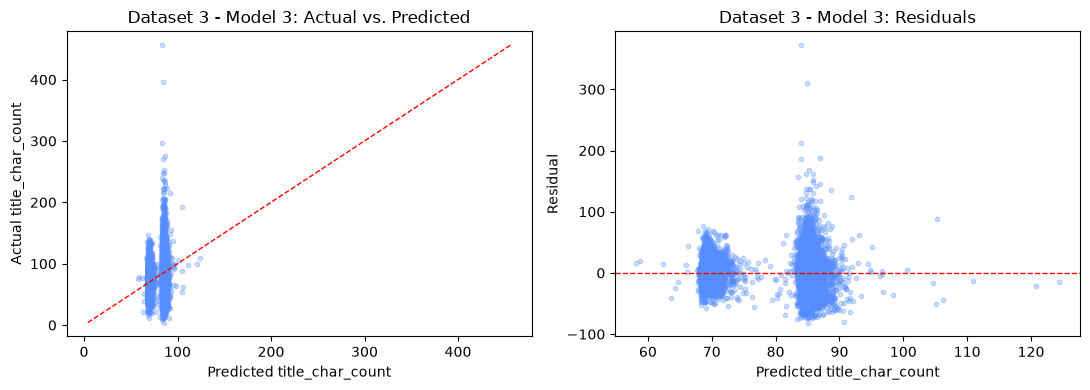

In [61]:
# Compare all three models, and inspect residuals for the final model
comparison = pd.DataFrame(results).set_index("model")
print(comparison)

y_pred_final = model_3.predict(X_test_3_scaled)
residuals = y_test.values - y_pred_final

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(y_pred_final, y_test, alpha=0.3, s=10)
lims = [min(y_test.min(), y_pred_final.min()), max(y_test.max(), y_pred_final.max())]
axes[0].plot(lims, lims, "r--", linewidth=1)
axes[0].set_xlabel("Predicted title_char_count")
axes[0].set_ylabel("Actual title_char_count")
axes[0].set_title("Dataset 3 - Model 3: Actual vs. Predicted")

axes[1].scatter(y_pred_final, residuals, alpha=0.3, s=10)
axes[1].axhline(0, color="r", linestyle="--", linewidth=1)
axes[1].set_xlabel("Predicted title_char_count")
axes[1].set_ylabel("Residual")
axes[1].set_title("Dataset 3 - Model 3: Residuals")

plt.tight_layout()
plt.show()


**Dataset 3 takeaways:** with essentially no multicollinearity among the text-based predictors (all VIFs under 2.1, none over the VIF > 10 threshold), Lasso, Ridge, and Elastic Net all land within half a point of R^2 = 0.11 of each other - almost exactly reproducing Part 1's finding (0.109 / 0.109 / 0.113) that headline length is mostly unrelated to these body-text statistics, regardless of which linear technique is used. Lasso does zero out text_avg_word_length and text_question_count, but since those coefficients were already small and uncorrelated with anything else, dropping them changes almost nothing. This dataset is the cleanest illustration in either part of this assignment that regularization is a remedy for multicollinearity, not a cure for a genuinely weak relationship - no amount of shrinkage, selection, or added nonlinear structure manufactures predictive power that was not there in the data.

# Conclusion & Observations

Part 2 repeats Part 1's three regression problems - unchanged targets, predictors, and train/test splits - but swaps the modeling strategy: instead of an OLS baseline, a VIF-driven feature-dropping step, and a small polynomial/interaction expansion, every dataset now goes through Lasso (L1), Ridge (L2), and Elastic Net (L1 + L2), each with its regularization strength chosen by cross-validation, on features standardized with `StandardScaler`.

The headline result is consistent across all three datasets: Elastic Net, applied to the same polynomial/interaction-expanded feature set used in Part 1, is the strongest model every time (R^2 = 0.657, 0.617, and 0.113 for Datasets 1-3), and in every case its cross-validated l1_ratio converged to 1.0 - meaning the extra L2 term Elastic Net can add never actually helped here, and a pure Lasso penalty was preferred. That is a reasonable outcome given the shape of the redundancy in these datasets: it is concentrated in one or two clearly duplicated features (Total Backward Packets and its length counterpart) rather than spread diffusely across many correlated ones, which is exactly the setting where L1's ability to zero out a specific feature outperforms L2's tendency to shrink everything a little.

Lasso and Ridge tell a more interesting story in comparison to each other. On Dataset 1, where the redundant features are still individually informative, neither penalty is strong enough at its chosen alpha to zero anything out, and the two methods perform almost identically (0.454 vs. 0.454) - both comfortably matching Part 1's OLS baseline without needing a human judgment call about which feature to drop. On Dataset 2, the most collinear of the three (VIFs up to ~141), Lasso's willingness to zero out Total Backward Packets and a redundant categorical dummy gives it a real edge over Ridge (0.423 vs. 0.392) - concrete evidence that when multicollinearity is concentrated in a few features rather than spread out, explicit selection beats uniform shrinkage. On Dataset 3, where the VIF check finds essentially no multicollinearity at all, Lasso, Ridge, and Elastic Net converge to nearly the same answer (0.109-0.113), just as Part 1's baseline and VIF-reduced models did (they were identical, since nothing needed dropping).

Put together, Parts 1 and 2 make the same point from opposite directions. Part 1 showed that manually dropping a high-VIF feature can *hurt* prediction when that feature is redundant but still informative, and that the real fix for a weak model is adding the right nonlinear structure, not just handling multicollinearity. Part 2 confirms this: regularization removes the need to manually choose which correlated feature to discard - and, in the one dataset where the redundancy really was concentrated and disposable (Dataset 2), Lasso's automatic selection improved on Ridge's uniform shrinkage the same way - but it does not, by itself, raise a model's ceiling. The same Packet Length Mean / Flow IAT Mean polynomial and interaction terms that lifted Part 1's Model 3 past its collinear baseline are still what separates the best model from the rest here.